**Author:** Salvador Navas  
**Date:** 2025-06-27

### GPM 3IMERG

**GPM 3IMERG (Global Precipitation Measurement Integrated Multi-satellite Retrievals for GPM Final Run)** is a high-resolution global precipitation product produced by NASA as part of the **Global Precipitation Measurement (GPM) mission**.

- **Data type:** Multi-satellite precipitation estimates combining microwave and infrared sensors, calibrated with GPM Core Observatory radar and adjusted with rain gauge data (GPCC) in the Final Run.
- **Spatial resolution:** ~0.1° (approximately 10 km).
- **Temporal resolution:** Available at
  - **Hourly** (aggregated from half-hourly)
  - **Daily** (preprocessed daily accumulation products)
  - **Monthly** (preprocessed monthly accumulation products)
- **Temporal coverage:** From January 1998 (TRMM-era) to present.
- **Spatial coverage:** Global, between 60°S and 60°N.

#### 💡 **Key characteristics:**

1. **IMERG (Integrated Multi-satellitE Retrievals for GPM)** combines observations from multiple passive microwave sensors aboard different satellites, calibrated against the GPM Core Observatory's Dual-frequency Precipitation Radar (DPR).
2. **Gauge-adjusted Final Run (3IMERG)** integrates ground-based rain gauge data (GPCC) to reduce bias and improve accuracy.
3. Provides high-quality precipitation data for hydrological modeling, climate studies, flood monitoring, and agricultural applications.
4. Offers **three processing levels**:
   - **Early Run:** Near real-time (~4 hours latency), no gauge correction.
   - **Late Run:** Delayed (~14 hours latency), no gauge correction.
   - **Final Run (3IMERG):** Gauge-corrected, with ~3 months latency.

#### 🔗 **Technical reference:**

- Huffman, G. J., Bolvin, D. T., Braithwaite, D., et al. (2019). NASA Global Precipitation Measurement (GPM) Integrated Multi-satellitE Retrievals for GPM (IMERG). *Algorithm Theoretical Basis Document (ATBD)* Version 06. NASA. https://doi.org/10.5067/GPM/IMERG/3B-HH/06


In [1]:
from HYDRA.Climate.DW_GlobalData.GPM import GPMDownloader
from HYDRA.utils import interactive_map

In [2]:
# Llamar a la función para visualizar el mapa y capturar las coordenadas seleccionadas
coordinates_list = interactive_map(zoom=4, center=(20, 0))

In [3]:
# 1. Create the downloader and authenticate
gpm = GPMDownloader()

# 2. Define the region of interest (points or bounding box)
# Option 1: Define multiple points
points = [(39.392231, -0.624717)]  # Valencia
gpm.set_region(points=points)

# Option 2: Define a bounding box directly (e.g., a small area around Madrid)
# gpm.set_region(lat_bounds=(40.3, 40.5), lon_bounds=(-3.8, -3.6))

# 3. Search for available granules
results = gpm.search(
    start_date='2024-10-01',
    end_date='2024-10-31',
    resolution="hourly"
)
# 4. Open and extract data from the downloaded granules
data = gpm.open_dataset(results, variable="precipitation",output_folder='gpm_data')

🔄 Overall progress: 100%|██████████| 31/31 [09:33<00:00, 18.50s/it]

✅ Saved combined CSV: gpm_data\precipitation_points.csv


<Axes: xlabel='time'>

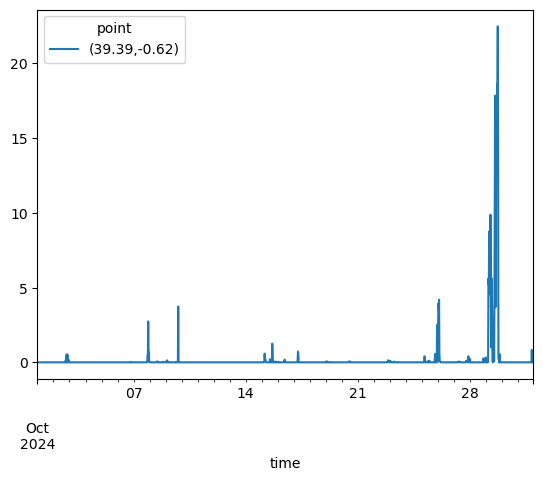

: 

In [ ]:
data.plot()